In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.datasets import load_iris
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, mean_squared_error, classification_report
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%matplotlib inline

pd.set_option('display.float_format', lambda x: '%.9f' % x)
np.set_printoptions(suppress=True, precision=9) # precision sets the number of decimal places


In [2]:
data = load_iris()
iris = pd.DataFrame(data.data, columns=data.feature_names)
iris['class'] = data.target
iris['class'] = pd.Categorical.from_codes(data.target, data.target_names)
iris['class'] = iris['class'].astype('category')
iris


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.099999999999999644729,3.500000000000000000000,1.399999999999999911182,0.200000000000000011102,setosa
1,4.900000000000000355271,3.000000000000000000000,1.399999999999999911182,0.200000000000000011102,setosa
2,4.700000000000000177636,3.200000000000000177636,1.300000000000000044409,0.200000000000000011102,setosa
3,4.599999999999999644729,3.100000000000000088818,1.500000000000000000000,0.200000000000000011102,setosa
4,5.000000000000000000000,3.600000000000000088818,1.399999999999999911182,0.200000000000000011102,setosa
...,...,...,...,...,...
145,6.700000000000000177636,3.000000000000000000000,5.200000000000000177636,2.299999999999999822364,virginica
146,6.299999999999999822364,2.500000000000000000000,5.000000000000000000000,1.899999999999999911182,virginica
147,6.500000000000000000000,3.000000000000000000000,5.200000000000000177636,2.000000000000000000000,virginica
148,6.200000000000000177636,3.399999999999999911182,5.400000000000000355271,2.299999999999999822364,virginica


In [3]:
iris.dtypes

sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
class                category
dtype: object

In [4]:
X = iris.iloc[:,:-1]
Y = iris.iloc[:, -1]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, shuffle=True)


In [150]:
class_mapping = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
y_train_numeric = y_train.map(class_mapping)
y_test_numeric = y_test.map(class_mapping)

## Assumptions of LDA

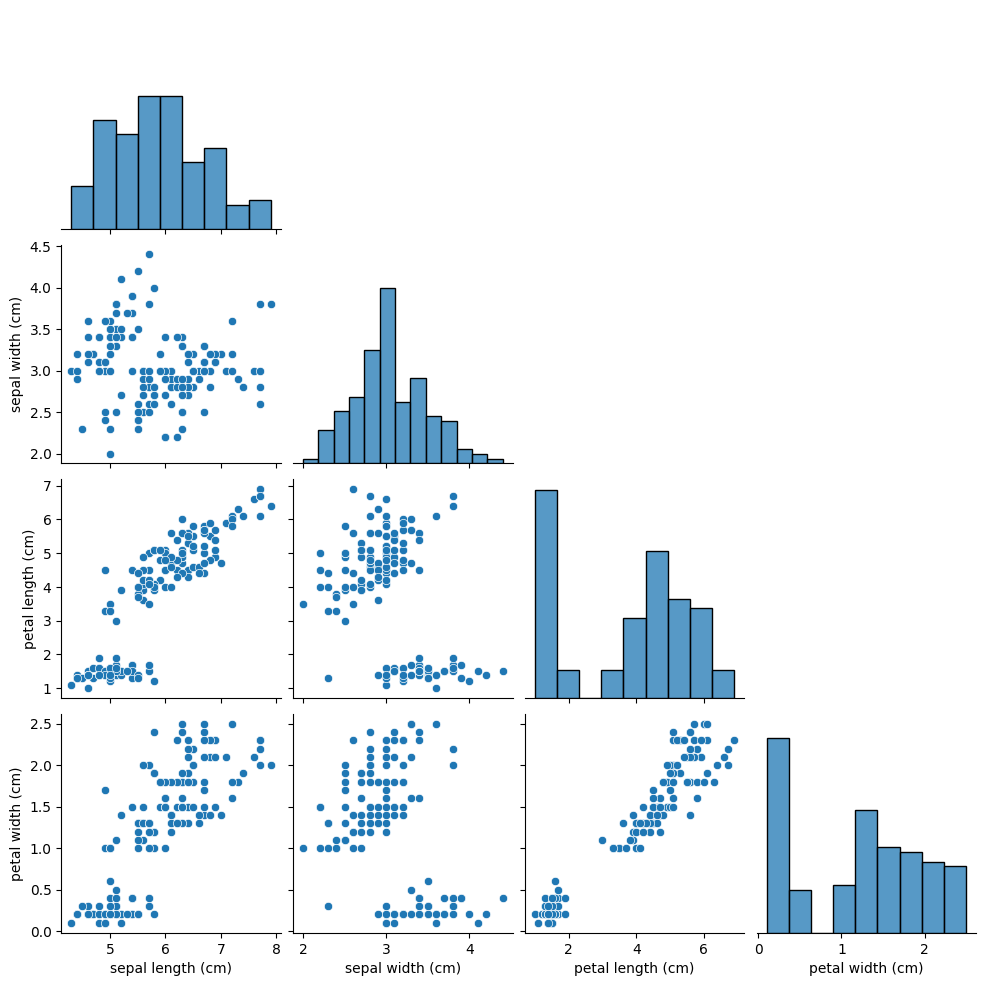

In [8]:
#normal distrubution of predictors
sns.pairplot(X, corner=True)

In [9]:
for i in X[data.feature_names]:
    print(f'skew of {i} - {X[i].skew()}')

skew of sepal length (cm) - 0.3149109566369728
skew of sepal width (cm) - 0.31896566471359966
skew of petal length (cm) - -0.27488417975101276
skew of petal width (cm) - -0.10296674764898116


<Axes: >

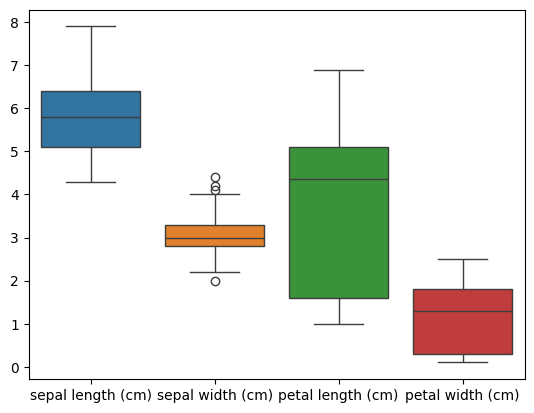

In [10]:
#same variance for predictors
sns.boxplot(X)

In [32]:
stats = X.describe().T
stats["Coeff_of_Var %"] = stats["std"] / stats["mean"] * 100
stats

,count,mean,std,min,25%,50%,75%,max,Coeff_of_Var %
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,14.171126
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4,14.256420
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9,46.974407
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5,63.555114


In [36]:
mad = np.mean(np.abs(X["sepal width (cm)"] - np.mean(X["sepal width (cm)"])))
mad

np.float64(0.33678222222222226)

## Linear Discriminant Analysis

In [38]:
model = LinearDiscriminantAnalysis()
lda = model.fit(X_train, y_train)
pred = lda.predict(X_test)
pred

array(['versicolor', 'versicolor', 'setosa', 'versicolor', 'setosa',
       'setosa', 'setosa', 'setosa', 'virginica', 'virginica',
       'versicolor', 'setosa', 'virginica', 'setosa', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'setosa',
       'setosa', 'versicolor', 'versicolor', 'setosa', 'versicolor',
       'versicolor', 'versicolor', 'setosa', 'versicolor', 'virginica'],
      dtype='<U10')

In [39]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X, Y, scoring='accuracy', cv=cv, n_jobs=-1)
print("Mean Accuracy:", np.mean(scores))  # Average accuracy
print("Standard Deviation:", np.std(scores))  

Mean Accuracy: 0.9800000000000001
Standard Deviation: 0.03055050463303893


In [40]:
new = [5, 3, 1, .4]
lda.predict([new])

C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


array(['setosa'], dtype='<U10')

In [45]:
#LDA for dimensionality reduction
dim_red = lda.transform(X)
print(X.shape)
print(dim_red.shape)

(150, 4)
(150, 2)


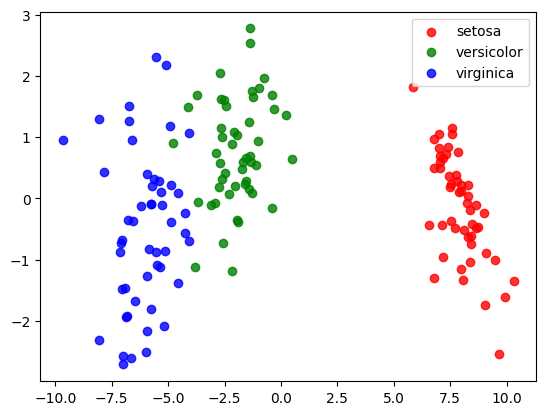

In [14]:
#create LDA plot
plt.figure()
colors = ['red', 'green', 'blue']

for color, i in zip(colors, data.target_names):
    plt.scatter(dim_red[Y == i, 0], dim_red[Y == i, 1], alpha=.8, color=color, label=i)

#add legend to plot
plt.legend(loc='best', shadow=False, scatterpoints=1)

#display LDA plot
plt.show()

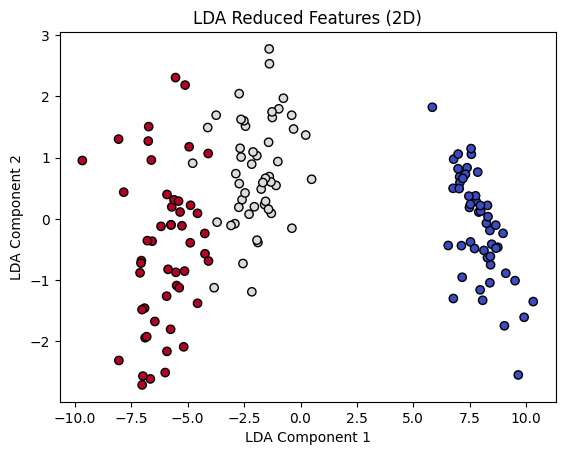

In [15]:
Y_encode = Y.apply(lambda x: 0 if x=="setosa" else 1 if x=="versicolor"  else 2 )
plt.scatter(dim_red[:, 0], dim_red[:, 1], c=Y_encode, cmap='coolwarm', edgecolors='k')
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA Reduced Features (2D)")
plt.show()

In [50]:
#LDA for feature selection
feature_importance = abs(lda.coef_).sum(axis=0)
important_features = np.argsort(feature_importance)[::-1]
print("Feature importance ranking:", important_features)

Feature importance ranking: [3 2 1 0]


## PCA

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=None)  # Preserve 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [18]:
#Covariance matrix for each feature pair
covariance_matrix = pca.get_covariance()
print("Covariance matrix:\n", covariance_matrix)

#Eigenvalues (variance explained by each component)
eigenvalues = pca.explained_variance_
print("\nEigenvalues:\n", eigenvalues)

#PCA loadings
pca_loadings = pca.components_
print("\nPCA loadings:\n", pca_loadings)

# Eigenvectors (Principal components)
eigenvectors = pca_loadings / np.sqrt(eigenvalues[:, np.newaxis])
print("\nEigenvectors:\n", eigenvectors)

Covariance matrix:
 [[ 1.00840336 -0.17112344  0.87368107  0.82829623]
 [-0.17112344  1.00840336 -0.49129877 -0.42151136]
 [ 0.87368107 -0.49129877  1.00840336  0.97119859]
 [ 0.82829623 -0.42151136  0.97119859  1.00840336]]

Eigenvalues:
 [2.99421847 0.87342668 0.14388247 0.02208582]

PCA loadings:
 [[ 0.51274515 -0.30524695  0.57490055  0.55982681]
 [ 0.40945261  0.90765376  0.0327376   0.0862639 ]
 [ 0.71458238 -0.25664433 -0.15911616 -0.6310212 ]
 [-0.24251389  0.13085348  0.80193494 -0.53006106]]

Eigenvectors:
 [[ 0.29631922 -0.17640447  0.33223928  0.32352806]
 [ 0.43811731  0.97119622  0.03502947  0.09230301]
 [ 1.88385884 -0.67659335 -0.4194791  -1.66356588]
 [-1.6318486   0.88049832  5.39612972 -3.56672101]]


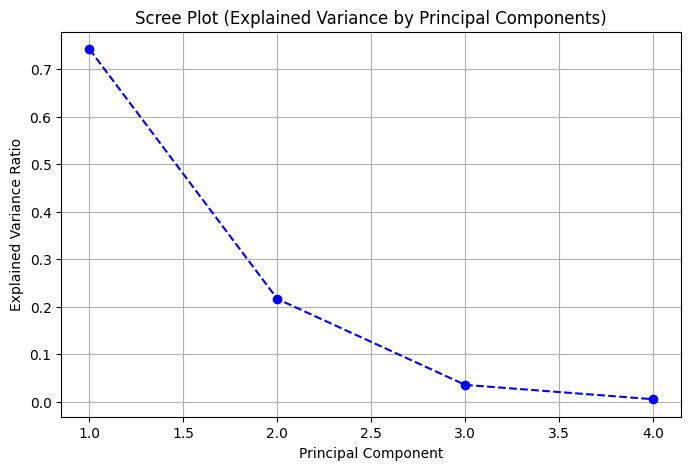

In [19]:
# Plot the explained variance (Scree Plot)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--', color='b')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (Explained Variance by Principal Components)')
plt.grid(True)
plt.show()

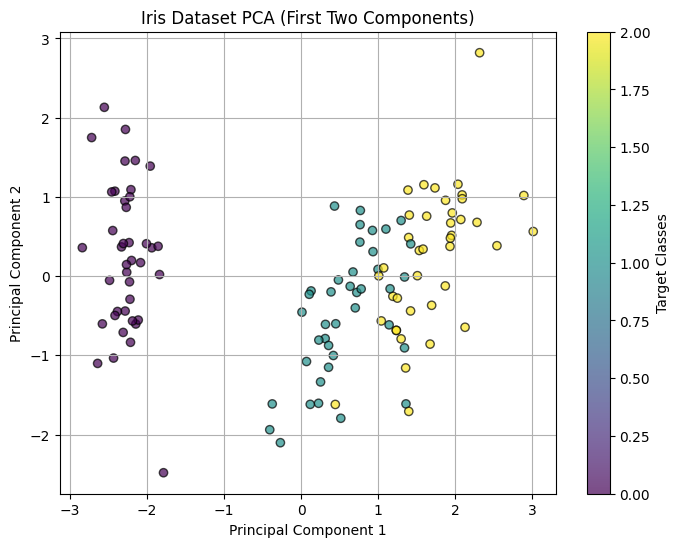

In [20]:
# Scatter plot of the first two principal components
plt.figure(figsize=(8, 6))

# Color by target class
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_numeric, cmap='viridis', edgecolor='k', alpha=0.7)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Iris Dataset PCA (First Two Components)')
plt.colorbar(scatter, label='Target Classes')
plt.grid(True)

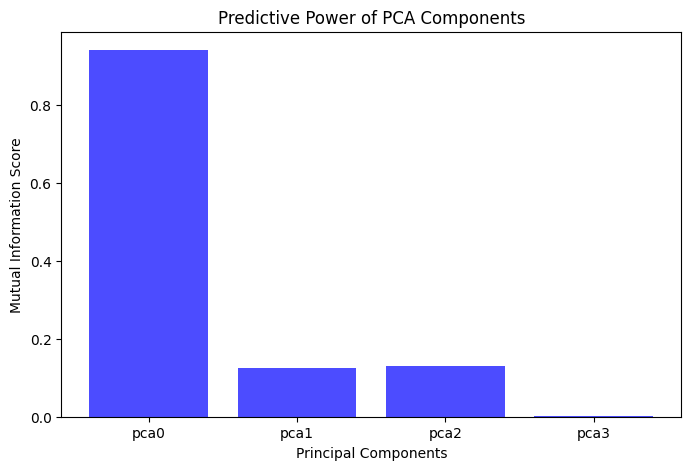

In [21]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train_pca, y_train, discrete_features=False)
pc_names = pca.get_feature_names_out().tolist()
mi_df = pd.DataFrame({'Principal Component': pca.get_feature_names_out().tolist(), 'MI Score': mi_scores})
plt.figure(figsize=(8, 5))
plt.bar(mi_df['Principal Component'], mi_df['MI Score'], color='blue', alpha=0.7)
plt.xlabel("Principal Components")
plt.ylabel("Mutual Information Score")
plt.title("Predictive Power of PCA Components")
plt.show()

In [55]:
# Check PCA loadings (contribution of original features to PCs)
loadings = pd.DataFrame(pca.components_, columns=X_train.columns, index=pc_names)
print("\nPCA Loadings (Feature Contributions to PCs):")
loadings


PCA Loadings (Feature Contributions to PCs):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
pca0,0.512745,-0.305247,0.574901,0.559827
pca1,0.409453,0.907654,0.032738,0.086264
pca2,0.714582,-0.256644,-0.159116,-0.631021
pca3,-0.242514,0.130853,0.801935,-0.530061


In [57]:
loadings = pd.DataFrame(pca.components_.T, columns=pc_names, index=X_train.columns)
print("\nPCA Loadings (Feature Contributions to PCs):")
loadings


PCA Loadings (Feature Contributions to PCs):


,pca0,pca1,pca2,pca3
sepal length (cm),0.512745,0.409453,0.714582,-0.242514
sepal width (cm),-0.305247,0.907654,-0.256644,0.130853
petal length (cm),0.574901,0.032738,-0.159116,0.801935
petal width (cm),0.559827,0.086264,-0.631021,-0.530061


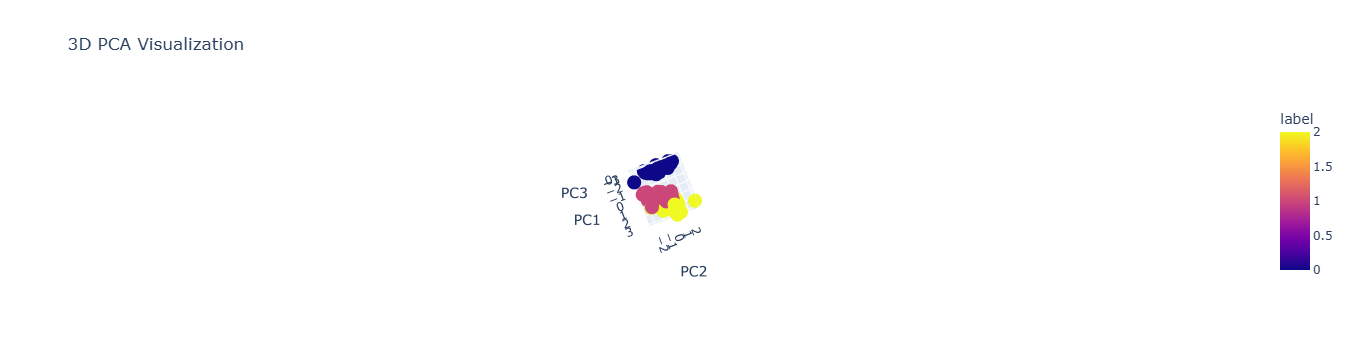

In [54]:
df_pca = pd.DataFrame(X_train_pca[:,:-1], columns=['PC1', 'PC2', 'PC3'])
df_pca['label'] = y_train_numeric  # if you have labels (e.g., for coloring)

fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
                    color='label',  # or remove if unlabeled
                    title='3D PCA Visualization')
fig.show()

## Kernel PCA

In [40]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components = 3, kernel = 'rbf')
kpca_train = kpca.fit_transform(X_train_scaled)
kpca_test = kpca.transform(X_test_scaled)

In [41]:
kpca.eigenvalues_

array([32.11843709, 14.0681107 ,  7.02509703])

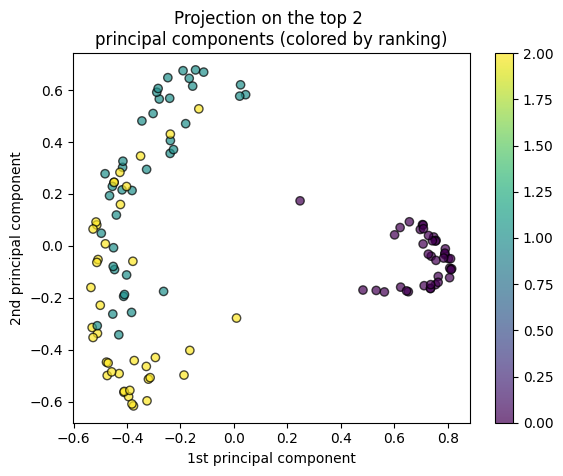

In [53]:
fig, ax = plt.subplots()

sc=ax.scatter(kpca_train[:,0],kpca_train[:,1] ,c=y_train_numeric, cmap='viridis', edgecolor='k', alpha=0.7)
fig.colorbar(sc, orientation='vertical')
#ax.annotate(industrys[ranking], (kpca_train[ranking,0],kernel_score[ranking,1]))
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.title("Projection on the top 2 \nprincipal components (colored by ranking)")
plt.show()

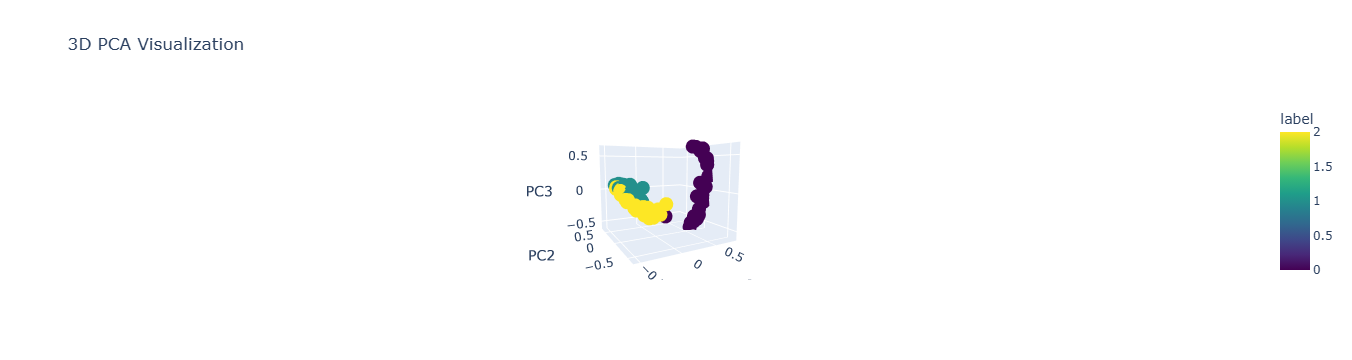

In [49]:
df_kpca = pd.DataFrame(kpca_train, columns=['PC1', 'PC2', 'PC3'])
df_kpca['label'] = y_train_numeric  # if you have labels (e.g., for coloring)
fig = px.scatter_3d(df_kpca, x='PC1', y='PC2', z='PC3',
                    color='label',  
                    color_continuous_scale='viridis',
                    title='3D PCA Visualization')
fig.show()

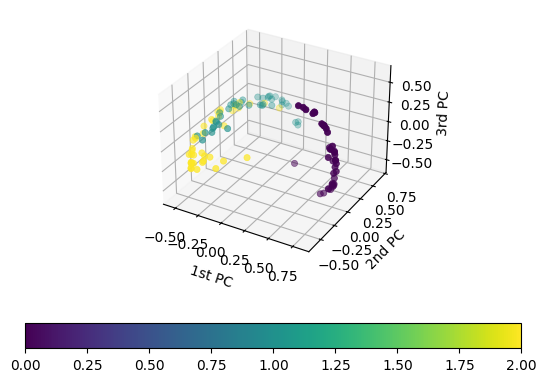

In [51]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
sc=ax.scatter(kpca_train[:,0], kpca_train[:,1],  kpca_train[:,2], c=y_train_numeric, cmap='viridis', linewidth=0.5);
fig.colorbar(sc, orientation='horizontal')
ax.set_xlabel('1st PC')
ax.set_ylabel('2nd PC')
ax.set_zlabel('3rd PC')
plt.show()

In [163]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

C:\Users\EdwinVivekN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=0)

In [164]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 8  0  0]
 [ 0 13  0]
 [ 0  0  9]]


1.0

In [165]:
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

## t-SNE

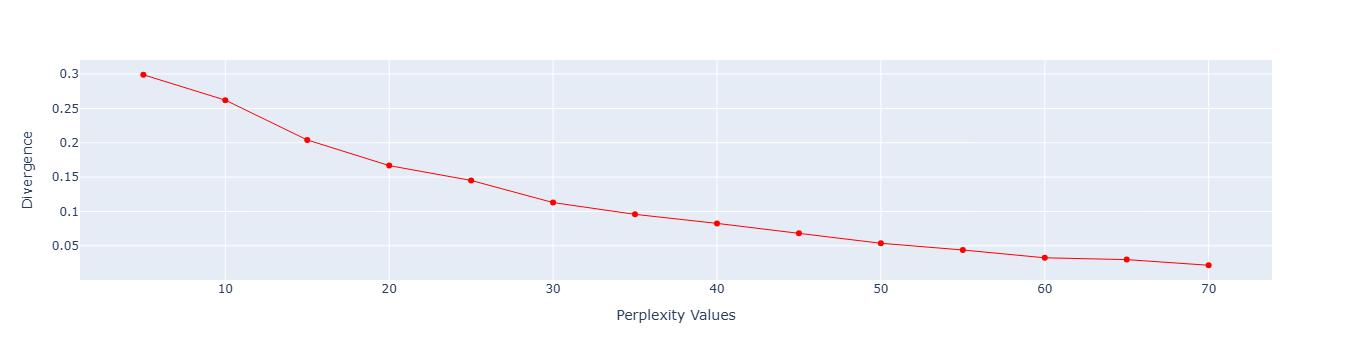

In [176]:
from sklearn.manifold import TSNE
import plotly.express as px
perplexity = np.arange(5, 75, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    reduced = model.fit_transform(X_train_scaled)
    divergence.append(model.kl_divergence_)
fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show()

KL-Divergence: 0.053696174174547195


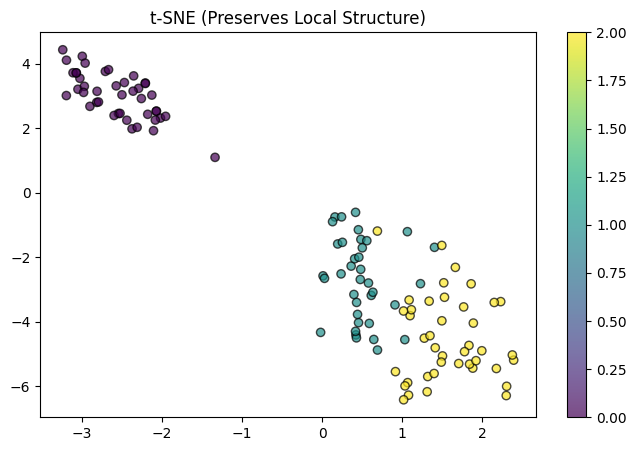

In [179]:
# Apply t-SNE (reduces to 2D while preserving local structure)
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)
print(f'KL-Divergence: {tsne.kl_divergence_}')

# Plot t-SNE results
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train_numeric, cmap='viridis', edgecolor='k', alpha=0.7)
fig.colorbar(sc, orientation='vertical')
ax.set_title("t-SNE (Preserves Local Structure)")
plt.show()

In [186]:
# Filter points in the top-left quadrant
setosa_indices = np.where((X_tsne[:, 0] < -1) & (X_tsne[:, 1] > 1.5))[0]  # Adjust the threshold if needed

print(f"Indices of Setosa in t-SNE: {np.shape(setosa_indices)}")

Indices of Setosa in t-SNE: (41,)


In [207]:
#Relating the cluster indexes back to actual data
pd.concat([X_train.iloc[setosa_indices, :], y_train.iloc[setosa_indices]], axis=1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
13,4.3,3.0,1.1,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
31,5.4,3.4,1.5,0.4,setosa
37,4.9,3.6,1.4,0.1,setosa
24,4.8,3.4,1.9,0.2,setosa
11,4.8,3.4,1.6,0.2,setosa
21,5.1,3.7,1.5,0.4,setosa
9,4.9,3.1,1.5,0.1,setosa
23,5.1,3.3,1.7,0.5,setosa
48,5.3,3.7,1.5,0.2,setosa


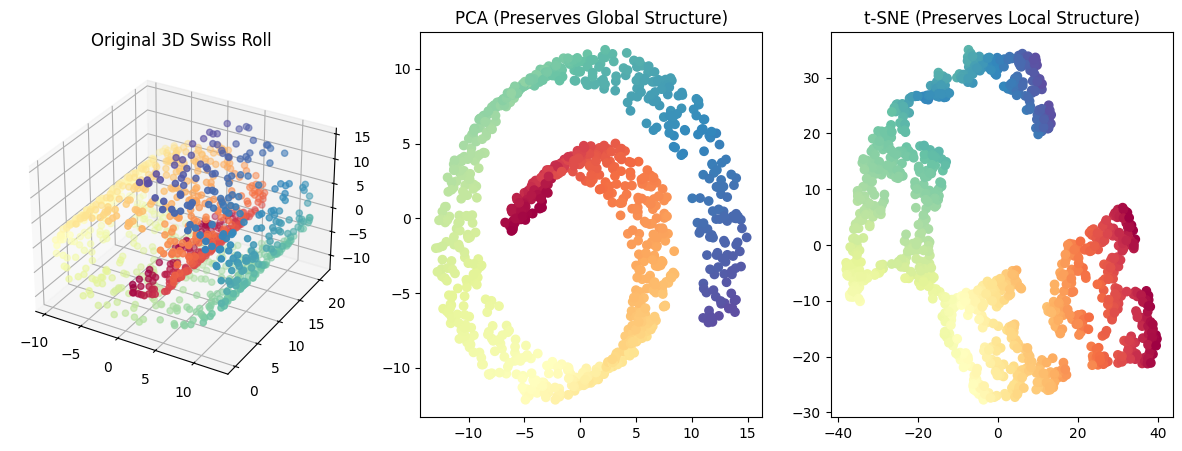

In [155]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Generate Swiss Roll dataset
n_samples = 1000
X, color = make_swiss_roll(n_samples, noise=0.1)

# Apply PCA (reduces to 2D while preserving global structure)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply t-SNE (reduces to 2D while preserving local structure)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plot original 3D Swiss Roll
fig = plt.figure(figsize=(15, 5))

ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax.set_title("Original 3D Swiss Roll")

# Plot PCA results
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap=plt.cm.Spectral)
ax2.set_title("PCA (Preserves Global Structure)")

# Plot t-SNE results
ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap=plt.cm.Spectral)
ax3.set_title("t-SNE (Preserves Local Structure)")

plt.show()

## KNN

In [27]:
# Standardize features
scaler = StandardScaler()
float_cols = X_train.select_dtypes(include=['float64']).columns
X_train[float_cols] = scaler.fit_transform(X_train[float_cols])
X_test[float_cols] = scaler.transform(X_test[float_cols])

# Train model
knn_clf = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn_clf.predict(X_test)
y_pred_prob = knn_clf.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9333333333333333


In [24]:
#choose k
k_values = np.arange(1, np.sqrt(X_train.shape[0]), dtype=int)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best K: {best_k}, Accuracy: {max(cv_scores):.4f}")

Best K: 8, Accuracy: 0.9667


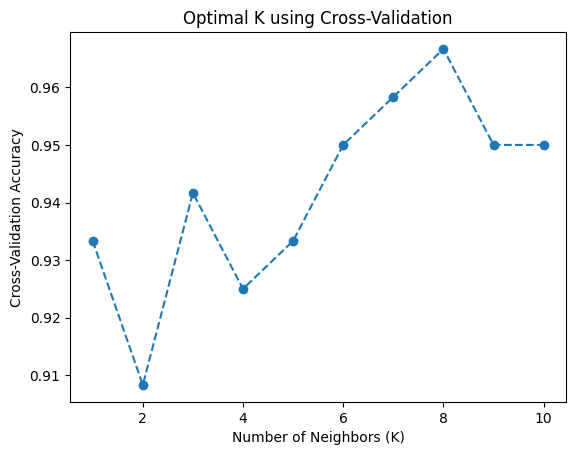

In [25]:
# Plot K vs. Cross-validation Accuracy
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Optimal K using Cross-Validation')
plt.show()

In [26]:
#elbow method
error_rates = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, y_pred))
    
                       
# Find the optimal K (Elbow Point)
best_k = k_values[np.argmin(error_rates)]
print(f"Best K (Elbow Point): {best_k}")                     
    

Best K (Elbow Point): 1


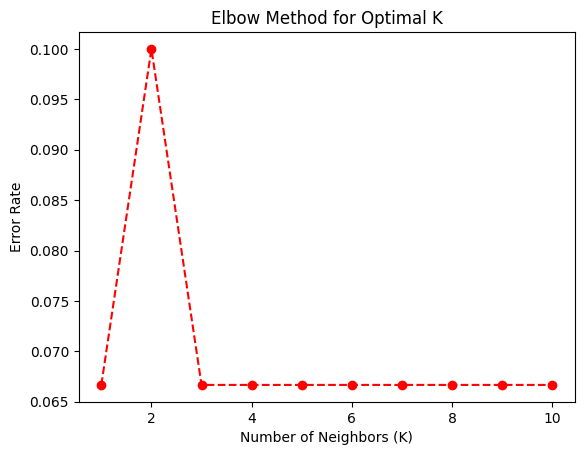

In [21]:
# Plot K vs. Error Rate
plt.plot(k_values, error_rates, marker='o', linestyle='dashed', color='red')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Optimal K')
plt.show()

In [31]:
# Compute multi-class ROC AUC score
auc_ovr = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')  # One-vs-Rest
print(f'auc_ovr: {auc_ovr}')
auc_ovo = roc_auc_score(y_test, y_pred_prob, multi_class='ovo')  # One-vs-One
print(f'auc_ovo: {auc_ovo}')


auc_ovr: 0.9961659381949236
auc_ovo: 0.9947089947089948


In [90]:
best_thresholds_roc = {}

for i, category in enumerate(y_test.unique().tolist()):  # 3 classes in Iris dataset
    fpr, tpr, thresholds = roc_curve([1 if label == category else 0 for label in y_test], y_pred_prob[:, i])
    j_scores = tpr - fpr  # Compute Youden's J score
    best_thresholds_roc[category] = thresholds[np.argmax(j_scores)]  # Best threshold

print("Best Thresholds (ROC-Based):", best_thresholds_roc)

Best Thresholds (ROC-Based): {'setosa': 0.6, 'versicolor': 0.8, 'virginica': 0.2}


In [93]:
def adjust_predictions(y_pred_prob, best_thresholds, class_names):
    adjusted_preds = []
    for probs in y_pred_prob:
        class_pred = np.argmax([1 if probs[i] >= best_thresholds[category] else 0 for i, category in enumerate(class_names)])
        #cat_pred = class_pred.apply(lambda x: "setosa" if x==0 else "ver")
        adjusted_preds.append(class_names[class_pred])
    return np.array(adjusted_preds)

# Adjust predictions using the new thresholds
y_adjusted_roc = adjust_predictions(y_pred_prob, best_thresholds_roc, y_test.unique().tolist())

print("Adjusted Predictions (ROC-Based Thresholds):", y_adjusted_roc)

Adjusted Predictions (ROC-Based Thresholds): ['setosa' 'versicolor' 'setosa' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'setosa' 'virginica' 'setosa' 'setosa' 'virginica' 'setosa'
 'setosa' 'setosa' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica']


In [95]:
from sklearn.metrics import classification_report

print("Original Predictions:\n", classification_report(y_test, y_pred))
print("\nROC-Adjusted Predictions:\n", classification_report(y_test, y_adjusted_roc))

Original Predictions:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.82      1.00      0.90         9
   virginica       1.00      0.71      0.83         7

    accuracy                           0.93        30
   macro avg       0.94      0.90      0.91        30
weighted avg       0.95      0.93      0.93        30


ROC-Adjusted Predictions:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.86      0.92         7

    accuracy                           0.97        30
   macro avg       0.97      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



## Decision Tree

In [134]:
def compare_models(m1, m2):
    f = plt.figure(figsize=(20,18))
    ax = f.add_subplot(221)
    tree.plot_tree(m1.fit(X, Y), class_names=data.target_names, feature_names=data.feature_names, filled=True, node_ids=True, rounded=True, ax= ax, fontsize=15)
    ax2 = f.add_subplot(222)
    tree.plot_tree(m2.fit(X, Y),class_names=data.target_names, feature_names=data.feature_names, filled=True, node_ids=True, rounded=True, ax= ax2, fontsize=15)

In [129]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3, splitter='best')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print ("Accuracy Score : ", accuracy_score(y_test,y_pred)*100) 

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Accuracy Score :  96.66666666666667


In [132]:
model2 = DecisionTreeClassifier(criterion='gini', max_depth=5, splitter='best', min_samples_split=50, 
                                min_samples_leaf= 20, min_impurity_decrease=0.1)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print ("Accuracy Score 2 : ", accuracy_score(y_test,y_pred)*100) 

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,50
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.1
,class_weight,None


Accuracy Score 2 :  96.66666666666667


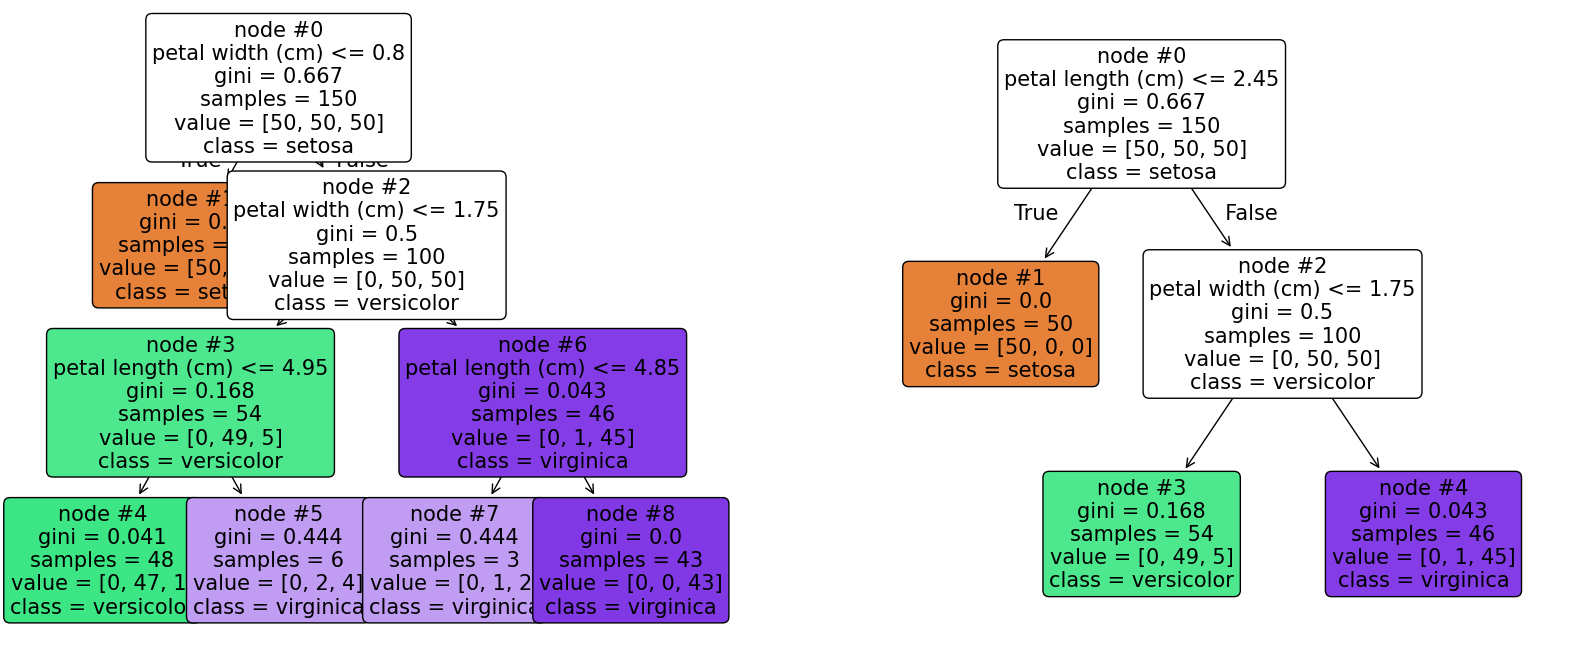

In [135]:
compare_models(model, model2)

In [136]:
#post pruning using Cross validation
def run_cross_validation_on_trees(X, y, tree_depths, cv=5, scoring='accuracy'):
    cv_scores_list = []
    cv_scores_std = []
    cv_scores_mean = []
    accuracy_scores = []
    for depth in tree_depths:
        tree_model = DecisionTreeClassifier(max_depth=depth)
        cv_scores = cross_val_score(tree_model, X, y, cv=cv, scoring=scoring)
        cv_scores_list.append(cv_scores)
        cv_scores_mean.append(cv_scores.mean())
        cv_scores_std.append(cv_scores.std())
        accuracy_scores.append(tree_model.fit(X, y).score(X, y))
    cv_scores_mean = np.array(cv_scores_mean)
    cv_scores_std = np.array(cv_scores_std)
    accuracy_scores = np.array(accuracy_scores)
    return cv_scores_mean, cv_scores_std, accuracy_scores, cv_scores_list

def plot_cross_validation_on_trees(depths, cv_scores_mean, cv_scores_std, accuracy_scores, title):
    fig, ax = plt.subplots(1,1, figsize=(15,5))
    ax.plot(depths, cv_scores_mean, '-o', label='mean cross-validation accuracy', alpha=0.9)
    ax.fill_between(depths, cv_scores_mean-2*cv_scores_std, cv_scores_mean+2*cv_scores_std, alpha=0.2)
    ylim = plt.ylim()
    ax.plot(depths, accuracy_scores, '-*', label='train accuracy', alpha=0.9)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Tree depth', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_ylim(ylim)
    ax.set_xticks(depths)
    ax.legend()

In [137]:
# fitting trees of depth 1 to 5
sm_tree_depths = range(1,6)
sm_cv_scores_mean, sm_cv_scores_std, sm_accuracy_scores, sm_cv_scores_list = run_cross_validation_on_trees(X, Y, 
                                                                                        sm_tree_depths)

print(sm_accuracy_scores)
print(sm_cv_scores_mean)
print(sm_cv_scores_list)

[0.666666667 0.96        0.973333333 0.993333333 1.         ]
[0.666666667 0.933333333 0.96        0.966666667 0.966666667]
[array([0.666666667, 0.666666667, 0.666666667, 0.666666667, 0.666666667]), array([0.933333333, 0.966666667, 0.9        , 0.866666667, 1.         ]), array([0.966666667, 0.966666667, 0.933333333, 0.933333333, 1.         ]), array([0.966666667, 0.966666667, 0.9        , 1.         , 1.         ]), array([0.966666667, 0.966666667, 0.9        , 1.         , 1.         ])]


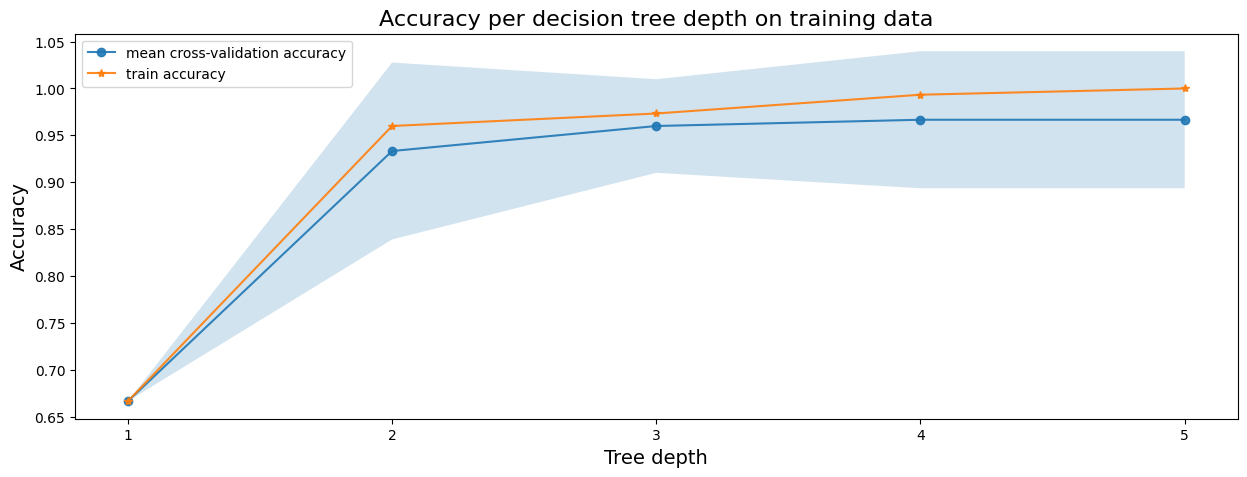

In [138]:
# plotting accuracy
plot_cross_validation_on_trees(sm_tree_depths, sm_cv_scores_mean, sm_cv_scores_std, sm_accuracy_scores, 
                               'Accuracy per decision tree depth on training data')

In [139]:
idx_max = sm_cv_scores_mean.argmax()
sm_best_tree_depth = sm_tree_depths[idx_max]
sm_best_tree_cv_score = sm_cv_scores_mean[idx_max]
sm_best_tree_cv_score_std = sm_cv_scores_std[idx_max]
print('The depth-{} tree achieves the best mean cross-validation accuracy {} +/- {}% on training dataset'.format(
      sm_best_tree_depth, round(sm_best_tree_cv_score*100,5), round(sm_best_tree_cv_score_std*100, 5)))


The depth-4 tree achieves the best mean cross-validation accuracy 96.66667 +/- 3.65148% on training dataset


In [140]:
#Grid search CV
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth':range(1,6)}
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1) #cross validation
gridcv = GridSearchCV(tree.DecisionTreeClassifier(), parameters, n_jobs=5, cv=cv)
gridcv.fit(X, Y)
modelcv = gridcv.best_estimator_
print (gridcv.best_score_, gridcv.best_params_) 

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': range(1, 6)}"
,scoring,None
,n_jobs,5
,refit,True
,cv,RepeatedStrat...andom_state=1)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


0.9466666666666668 {'max_depth': 3}


## SVC

In [50]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train)

y_test_numeric = np.array([class_mapping[label] for label in y_test])
y_pred_svc = svm_clf.predict(X_test)
accuracy_score(y_test, y_pred_svc)

0.9333333333333333

In [38]:
scores = svm_clf.decision_function((X_test[:1]))
scores

array([[ 2.22376616,  1.1769955 , -0.2534817 ]])

In [43]:
class_idx = np.argmax(scores)
data.target_names[class_idx]

'setosa'

## Multinomial Logistic Regression

In [84]:
softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=0.1)
softmax_reg.fit(X_train, y_train)
softmax_reg.predict(X_test[:1])

C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


array(['setosa'], dtype=object)

In [86]:
softmax_reg.predict_proba(X_test[:1])

array([[0.835421753, 0.162848141, 0.001730106]])

In [94]:
softmax_pred = softmax_reg.predict(X_test)
accuracy_score(y_test, softmax_pred)
confusion_matrix(y_test, softmax_pred)
print(classification_report(y_test, softmax_pred))

0.9666666666666667

array([[13,  0,  0],
       [ 0,  7,  0],
       [ 0,  1,  9]])

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.88      1.00      0.93         7
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [123]:
## decison function
scores = softmax_reg.decision_function(X_test)
setosa_scores = scores[:, 0]
top_indices = np.argsort(setosa_scores)[::-1][:10]
top_indices

array([13,  8, 27, 17,  6, 16, 14, 23,  5, 10])

In [105]:
threshold = np.percentile(scores, 99)
threshold

np.float64(3.5787397726718866)

In [120]:
import numpy as np

my_array = np.array([[10, 2, 9, -1], [9,8,7,6], [1,2,4,5], [4,1,4,4]])

# Get the indices that would sort the array
sorted_indices = np.argsort(my_array)[::-1]

print("Original Array:", my_array)
print("Indices of Sorted Array:", sorted_indices)
#print("Sorted Array:", my_array[sorted_indices])


Original Array: [[10  2  9 -1]
 [ 9  8  7  6]
 [ 1  2  4  5]
 [ 4  1  4  4]]
Indices of Sorted Array: [[1 0 2 3]
 [0 1 2 3]
 [3 2 1 0]
 [3 1 2 0]]


## OVR Logistic

In [13]:
ovr_reg = LogisticRegression(multi_class="ovr",solver="liblinear", C=10)
ovr_reg.fit(X_train, y_train)
ovr_reg.predict(X_test[:1])

C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


array(['setosa'], dtype=object)

In [54]:
ovr_reg.predict_proba(X_test[:1])

array([[0.728436072, 0.271563923, 0.000000005]])

### manual calculation

In [48]:
#The model has a matrix 3 X 4. Each row belongs to one of the 3 species.
#(n_classes, n_features)
#Row i contains weights for Class i vs. all others.

#               SL       SW         PL           PW
#  setosa      0.59
#  versicolor
#  virginica

ovr_reg.coef_

array([[ 0.59901837,  2.17294926, -3.36325093, -1.53191979],
       [ 0.60530546, -2.70158733,  0.4853099 , -1.63431695],
       [-3.12061144, -2.44099823,  4.55972352,  4.95232284]])

In [37]:
X_test[:1]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
25,5.000000000000000000000,3.000000000000000000000,1.600000000000000088818,0.200000000000000011102


In [43]:
# row 0 * coef 0  + bias
(5 * 0.59901837) + (3 *  2.17294926) + (1.6 * -3.36325093) + (0.2 * -1.53191979) +  0.399

4.225354184

In [46]:
# Calculate raw 'z' scores for all 3 models: (X * Weights) + Intercept
z = np.dot(X_test[:1], ovr_reg.coef_.T) + ovr_reg.intercept_
z

array([[  4.22572498,  -0.5432404 , -18.77411805]])

In [55]:
# Apply sigmoid to each score
raw_probs = 1 / (1 + np.exp(-z))
raw_probs

array([[0.985595778, 0.367434105, 0.000000007]])

In [56]:
# Normalize so they sum to 1.0 (as scikit-learn does for OvR)
final_probs = raw_probs / raw_probs.sum()
print(f"Manual Probabilities: {final_probs}")

Manual Probabilities: [[0.728436072 0.271563923 0.000000005]]


# Logistic OVO

In [60]:
from sklearn.multiclass import OneVsOneClassifier

# One-vs-One Classification
ovo_classifier = OneVsOneClassifier(LogisticRegression())
ovo_classifier.fit(X_train, y_train)

# Make predictions
y_pred_ovo = ovo_classifier.predict(X_test[:1])
y_pred_ovo
# Evaluate performance
#print(classification_report(y_test, y_pred_ovo))

array(['setosa'], dtype=object)

In [72]:
ovo_classifier.score(X_test, y_test)

0.9666666666666667

# XGBoost

In [183]:
from xgboost import XGBClassifier

params = {
    "n_estimators" : 50,    #no of trees to build
    "base_score": 0.5, # global error 
    "early_stopping_rounds": 5,  # check next 20 rounds and stop training if validation loss is not improved
    "objective" : "multi:softmax",  # loss functition to be optmized
    "eval_metric": "mlogloss",   # evaluation metric for early stopping
    "learning_rate": 0.1,  # controls the contribution of a tree
    "max_depth": 3,   # tree depth
    "gamma": 0,       # minimum loss reduction required to make a split
    "reg_alpha": 0,    # L1 regularization
    "reg_lambda": 1    # L2 regularization
}

xgb = XGBClassifier(**params, random_state=42)
xgb.fit(X_train, y_train_numeric, eval_set=[(X_test, y_test_numeric)], verbose=True)

[0]	validation_0-mlogloss:0.96798
[1]	validation_0-mlogloss:0.85612
[2]	validation_0-mlogloss:0.76091
[3]	validation_0-mlogloss:0.68078
[4]	validation_0-mlogloss:0.60960
[5]	validation_0-mlogloss:0.54898
[6]	validation_0-mlogloss:0.49433
[7]	validation_0-mlogloss:0.44744
[8]	validation_0-mlogloss:0.40595
[9]	validation_0-mlogloss:0.36909
[10]	validation_0-mlogloss:0.33484
[11]	validation_0-mlogloss:0.30558
[12]	validation_0-mlogloss:0.27793
[13]	validation_0-mlogloss:0.25318
[14]	validation_0-mlogloss:0.23137
[15]	validation_0-mlogloss:0.21142
[16]	validation_0-mlogloss:0.19391
[17]	validation_0-mlogloss:0.17823
[18]	validation_0-mlogloss:0.16448
[19]	validation_0-mlogloss:0.15122
[20]	validation_0-mlogloss:0.13967
[21]	validation_0-mlogloss:0.12949
[22]	validation_0-mlogloss:0.11963
[23]	validation_0-mlogloss:0.11130
[24]	validation_0-mlogloss:0.10351
[25]	validation_0-mlogloss:0.09666
[26]	validation_0-mlogloss:0.09041
[27]	validation_0-mlogloss:0.08453
[28]	validation_0-mlogloss:0.0

,objective,'multi:softmax'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,5
,enable_categorical,False
,eval_metric,'mlogloss'


In [184]:
print(f'Best iteration is {xgb.best_iteration} and \
   \n trainging best score is {xgb.evals_result()["validation_0"]["mlogloss"][xgb.best_iteration]} \
    \n validation best score is {xgb.best_score} after early stopping')

Best iteration is 49 and    
 trainging best score is 0.03421822475890319     
 validation best score is 0.03421822475890319 after early stopping


In [185]:
y_test_preds = xgb.predict(X_test)
accuracy_score(y_test_numeric, y_test_preds)

1.0

In [186]:
y_probs = xgb.predict_proba(X_test)
y_probs

array([[0.9834066  , 0.009125493, 0.007467875],
       [0.00585093 , 0.009319092, 0.9848299  ],
       [0.018497875, 0.9589655  , 0.022536723],
       [0.00880434 , 0.045884375, 0.94531125 ],
       [0.007931271, 0.078797914, 0.91327083 ],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.007662328, 0.98300236 , 0.009335324],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.020567095, 0.26899263 , 0.7104403  ],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.014518779, 0.9630281  , 0.022453189],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.008940219, 0.9801676  , 0.010892237],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.9850038  , 0.009140315, 0.00585579 ],
       [0.007528642, 0.98329896 , 0.009172454],
       [0.005857576, 0.00819392 , 0.98594856 ],
       [0.009279747, 0.039238233, 0.9514

In [187]:
#decision function equivalent in xgboost
scores = xgb.predict(X_test, output_margin=True)
scores

array([[ 3.1947947 , -1.4851559 , -1.6856174 ],
       [-1.8831075 , -1.4176428 ,  3.242761  ],
       [-1.8831075 ,  2.0650916 , -1.6856174 ],
       [-1.8831075 , -0.23222758,  2.793162  ],
       [-1.8831075 ,  0.41296577,  2.8631117 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [-1.8831075 ,  2.9711883 , -1.6856174 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [-1.8831075 ,  0.6878841 ,  1.6590849 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [-1.8831075 ,  2.3115323 , -1.4471174 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [-1.8831075 ,  2.814056  , -1.6856174 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [ 3.1947947 , -1.4851559 , -1.9304199 ],
       [-1.8831075 ,  2.9890912 , -1.6856174 ],
       [-1.8831075 , -1.5474505 ,  3.242761  ],
       [-1.8831075 , -0.44129047,  2.747

In [188]:
confidence = scores.max(axis=1)
confidence

array([3.1947947, 3.242761 , 2.0650916, 2.793162 , 2.8631117, 3.1947947,
       3.1947947, 2.9711883, 3.1947947, 1.6590849, 3.1947947, 2.3115323,
       3.1947947, 3.1947947, 3.1947947, 2.814056 , 3.1947947, 3.1947947,
       2.9890912, 3.242761 , 2.747079 , 3.242761 , 2.9711883, 3.1947947,
       3.0604966, 3.242761 , 3.242761 , 3.1947947, 3.1947947, 2.793162 ],
      dtype=float32)

In [189]:
#multi class ROC needs probabilities and not raw scores
roc_auc_score(y_test, y_probs, multi_class='ovr')

1.0

In [ ]:
# Evaluation

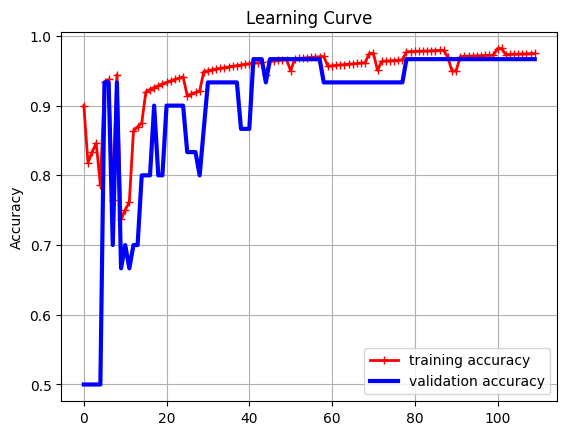

In [85]:
#learning curve
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_acc, val_acc = [], []
    for m in range(10, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_acc.append(accuracy_score(y_train[:m], y_train_predict))
        val_acc.append(accuracy_score(y_val, y_val_predict))
    plt.plot(train_acc, "r-+", linewidth=2, label="training accuracy")
    plt.plot(val_acc, "b-", linewidth=3, label="validation accuracy")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.title("Learning Curve")
    plt.show()

plot_learning_curves(svm_clf, X, Y)

In [62]:
#error analysis
y_train_pred =  cross_val_predict(svm_clf, X_train, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[41,  0,  0],
       [ 0, 44,  0],
       [ 0,  4, 31]], dtype=int64)

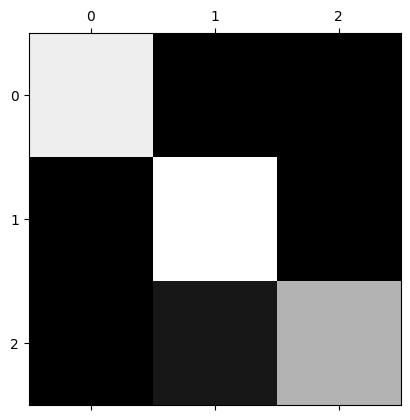

In [63]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

# 2 look slightly darker than the other classes, which could mean that there are fewer labels of 2s in the dataset or 
#that the classifier does not perform as well on class 2. 

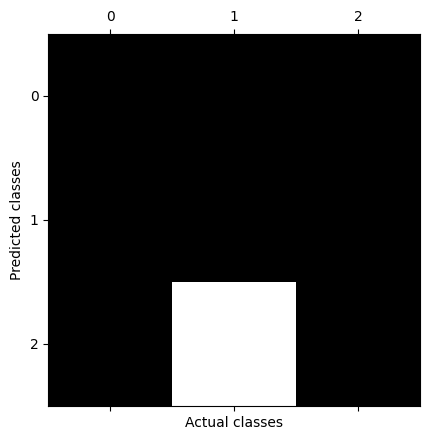

In [68]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.xlabel('Actual classes'); plt.ylabel('Predicted classes')
plt.show()

#(white) some of class 2 is predicted as class 1 here